In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB , MultinomialNB , BernoulliNB
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,accuracy_score,precision_score,classification_report
import nltk
from nltk.stem import PorterStemmer
from wordcloud import WordCloud



# what i am doing
 1. Data Cleaning
 2. EDA
 3. Text Preprocessing
 4. mmodel buiding
 5. Evaluation
 6. Improvement
 7. Website
 8. Deploy

In [62]:
df=pd.read_csv('spam_sms.csv')

In [63]:
df.head(7)

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...


In [64]:
df.shape

(5572, 2)

# Data Cleaning

In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   v1      5572 non-null   str  
 1   v2      5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [66]:
df.isnull().sum()
# no null value good for us


v1    0
v2    0
dtype: int64

In [67]:
# v1 and v2  is name of colums so not identify about columsn so rename it

df.rename(columns={'v1':"Target", 'v2':"Text"},inplace=True)

In [68]:
# we have to uniqe value ham and spam 
Lencoder= LabelEncoder()
df['Target']=Lencoder.fit_transform(df['Target'])

In [69]:
df.head()

,Target,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [70]:
# cheaking duplicated 
df.duplicated().sum()

np.int64(403)

In [71]:
#remove duplicated
df=df.drop_duplicates(keep='first')

In [72]:
# cheaking after delete duplicated 
df.duplicated().sum()

np.int64(0)

In [73]:
# cheaking shape after remove duplicate
df.shape

(5169, 2)

# 2.EDA

In [74]:
df.head()

,Target,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [75]:
df['Target'].value_counts()

Target
0    4516
1     653
Name: count, dtype: int64

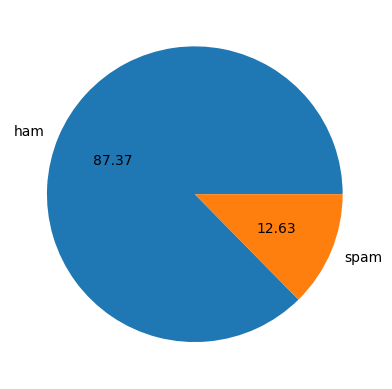

In [76]:
plt.pie(df['Target'].value_counts(),
         labels=['ham','spam'],
         autopct='%0.2f')
plt.show()

# so data is imbalanced

In [77]:
# storing all alpha and text 
df['all_characterText']= df['Text'].apply(len)

In [78]:
# now count words
df['num_word']=df['Text'].apply(lambda x: len(x.split()))

In [79]:
df

,Target,Text,all_characterText,num_word
0,0,"Go until jurong point, crazy.. Available only ...",111,20
1,0,Ok lar... Joking wif u oni...,29,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,0,U dun say so early hor... U c already then say...,49,11
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13
...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,30
5568,0,Will Ì_ b going to esplanade fr home?,37,8
5569,0,"Pity, * was in mood for that. So...any other s...",57,10
5570,0,The guy did some bitching but I acted like i'd...,125,26


In [80]:
# now cont sentance
import re

df['num_sentence'] = df['Text'].apply(
    lambda x: len([s for s in re.split(r'[.!?]+', x) if s.strip()])
)

In [81]:
df[['all_characterText','num_sentence','num_word']].describe()

,all_characterText,num_sentence,num_word
count,5169.000000,5169.000000,5169.000000
mean,78.977945,2.304508,15.340685
std,58.236293,1.639932,11.068488
min,2.000000,1.000000,1.000000
25%,36.000000,1.000000,7.000000
50%,60.000000,2.000000,12.000000
75%,117.000000,3.000000,22.000000
max,910.000000,31.000000,171.000000


In [82]:
# filter ham 
df[df['Target']==0][['all_characterText','num_sentence','num_word']].describe()

,all_characterText,num_sentence,num_word
count,4516.000000,4516.000000,4516.000000
mean,70.459256,2.099424,14.134632
std,56.358207,1.510418,11.116240
min,2.000000,1.000000,1.000000
25%,34.000000,1.000000,7.000000
50%,52.000000,2.000000,11.000000
75%,90.000000,3.000000,18.000000
max,910.000000,31.000000,171.000000


In [83]:
# filter with describe spam
df[df['Target']==1][['all_characterText','num_sentence','num_word']].describe()

,all_characterText,num_sentence,num_word
count,653.000000,653.000000,653.000000
mean,137.891271,3.722818,23.681470
std,30.137753,1.792465,5.967672
min,13.000000,1.000000,2.000000
25%,132.000000,2.000000,22.000000
50%,149.000000,4.000000,25.000000
75%,157.000000,5.000000,28.000000
max,224.000000,10.000000,35.000000


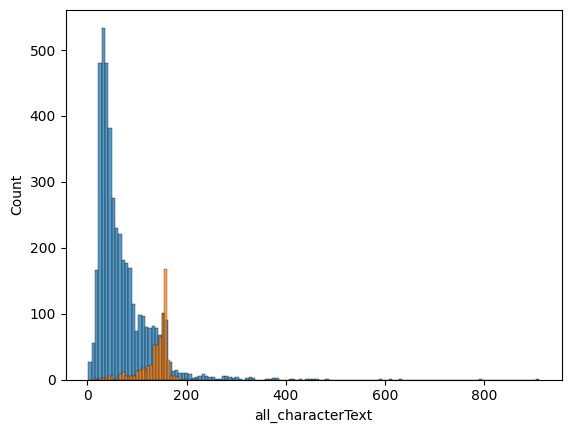

In [84]:
sns.histplot(df[df['Target']==0]['all_characterText'])
sns.histplot(df[df['Target']==1]['all_characterText'])
plt.show()

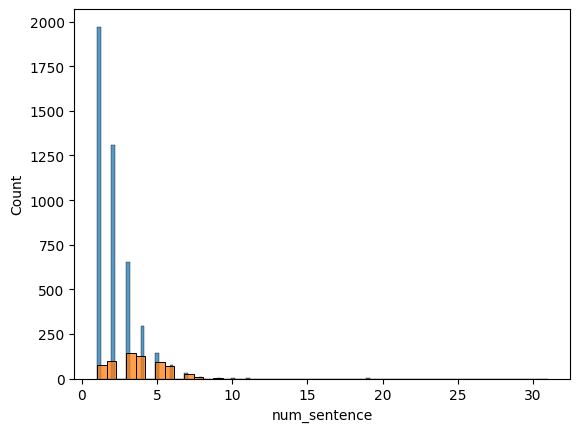

In [85]:
sns.histplot(df[df['Target']==0]['num_sentence'])
sns.histplot(df[df['Target']==1]['num_sentence'])
plt.show()

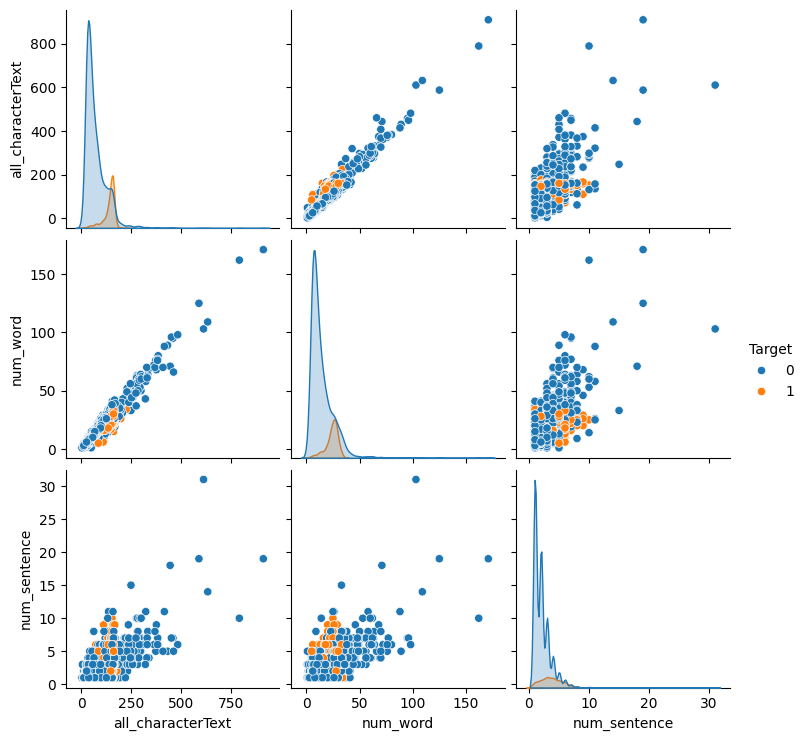

In [86]:
sns.pairplot(df,hue='Target')
plt.show()

<Axes: >

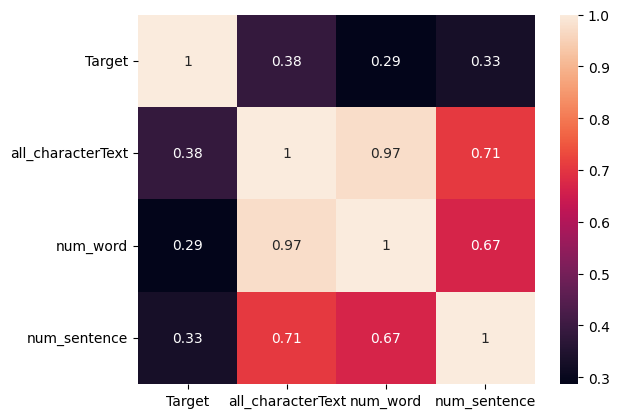

In [87]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

# 3 Data Preprocessing 
 Lower case
 tokenization
 Removing special characters
 Removing stop words and punctuation
 stemming

In [88]:
import string
ps=PorterStemmer()
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [89]:
import re

stopwords = {
    'i','me','my','we','our','you','your','he','she','it','they',
    'is','am','are','was','were','be','been','being',
    'have','has','had','do','does','did',
    'a','an','the','and','but','if','or','because',
    'as','until','while','of','at','by','for','with','about',
    'against','between','into','through','during','before','after',
    'above','below','to','from','up','down','in','out','on','off',
    'over','under','again','further','then','once'
}

def transform_text(Text):
    Text=Text.lower()
    Text=Text.split()
    
    y=[]
    for i in Text:
        if i.isalnum():
            y.append(i)

    Text=y[:]
    y.clear()

    for i in Text:
        if i not in stopwords and i not in string.punctuation:
            y.append(i)

    Text=y[:]
    y.clear()
    for i in Text:
        y.append(ps.stem(i))
    return " ".join(y)

In [90]:
transform_text('What you thinked about me. First time you saw me in class.')

'what think first time saw'

In [91]:
df['transfrom_text']= df['Text'].apply(transform_text)

In [92]:
df.head()

,Target,Text,all_characterText,num_word,num_sentence,transfrom_text
0,0,"Go until jurong point, crazy.. Available only ...",111,20,3,go jurong avail onli bugi n great world la e c...
1,0,Ok lar... Joking wif u oni...,29,6,2,ok joke wif u
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,11,2,u dun say so earli u c alreadi
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,1,nah think goe live around here though


In [130]:
from wordcloud import WordCloud

wc = WordCloud(width=800, height=400, background_color='white')


In [131]:
spam_wc= wc.generate(df[df['Target']==1]['transfrom_text'].str.cat(sep=" "))

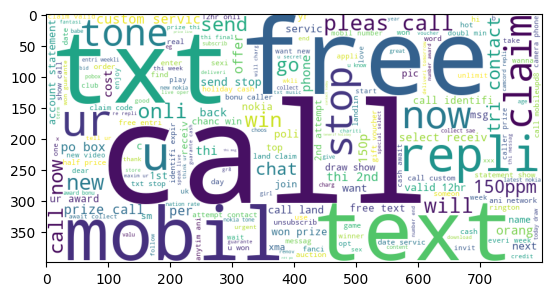

In [132]:
plt.imshow(spam_wc)
plt.show()

In [133]:
ham_wc= wc.generate(df[df['Target']==0]['transfrom_text'].str.cat(sep=" "))

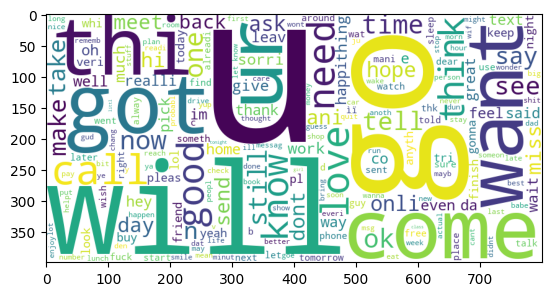

In [134]:
plt.imshow(ham_wc)
plt.show()

# steamming 
Stemming = reducing words to root form

Example:
playing → play
going → go
studies → studi

# 4 Model Building

In [98]:
# text transform

cv=CountVectorizer()
tfid=TfidfVectorizer(max_features=3000)

In [99]:

X=tfid.fit_transform(df['transfrom_text']).toarray()
y= df['Target'].values

In [100]:
# scaler = MinMaxScaler()
# X=scaler.fit_transform(X)

# after doing this precison is decreses so no need here 

In [101]:
X.shape

(5169, 3000)

In [102]:
X_train,X_test, y_train,y_test= train_test_split(X,y, test_size=0.2, random_state=42)

In [103]:
# decision Tree model 
dcm=DecisionTreeClassifier(max_depth=5,random_state=42)
dcm.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [105]:
y_pred = dcm.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("classification_report\n,{classificairon}")
print("precision score \n", precision_score(y_test,y_pred))

Accuracy: 0.9332688588007737
Confusion Matrix:
 [[873  16]
 [ 53  92]]
classification_report
,{classificairon}
precision score 
 0.8518518518518519


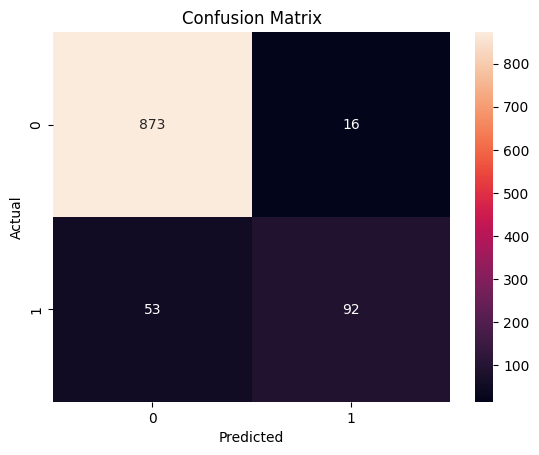

In [124]:

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# LogisticRegression

In [106]:
lgr = LogisticRegression()

lgr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [126]:
y_pred4 = lgr.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred4))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred4))

Accuracy: 0.9535783365570599

Confusion Matrix:

[[884   5]
 [ 43 102]]

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       889
           1       0.95      0.70      0.81       145

    accuracy                           0.95      1034
   macro avg       0.95      0.85      0.89      1034
weighted avg       0.95      0.95      0.95      1034



# for find it is spam or not the best is naive bayes so here i am using all nb like
 MUltinomilaNB   
 GaussianNB  
 BernoulliNB  

In [108]:
# model
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

## GaussianNB ()

In [109]:
# fit my data
gnb.fit(X_train,y_train)
y_pred1=gnb.predict(X_test)

print("here the report ")
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

here the report 
0.7988394584139265
[[701 188]
 [ 20 125]]
0.3993610223642173


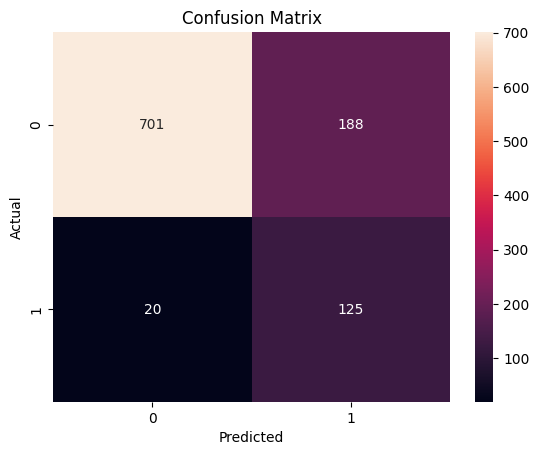

In [117]:
sns.heatmap(confusion_matrix(y_test, y_pred1), annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## MultinobialNB()

In [110]:
# fit my data
mnb.fit(X_train,y_train)
y_pred2=mnb.predict(X_test)

print("here the report ")
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

here the report 
0.9613152804642167
[[887   2]
 [ 38 107]]
0.981651376146789


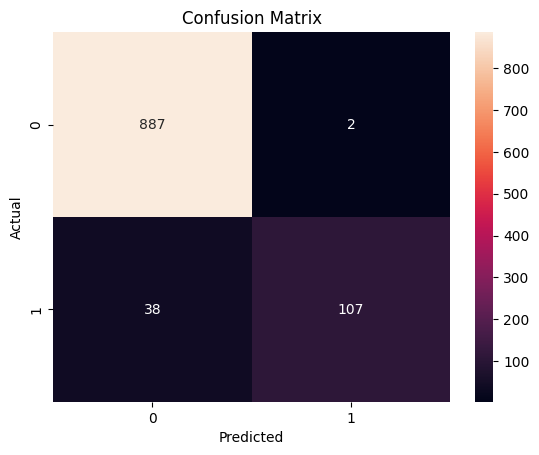

In [116]:

sns.heatmap(confusion_matrix(y_test, y_pred2), annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## BernoulliNB

In [112]:
# fit my data
bnb.fit(X_train,y_train)
y_pred3=bnb.predict(X_test)

print("here the report ")
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

here the report 
0.9690522243713733
[[885   4]
 [ 28 117]]
0.9669421487603306


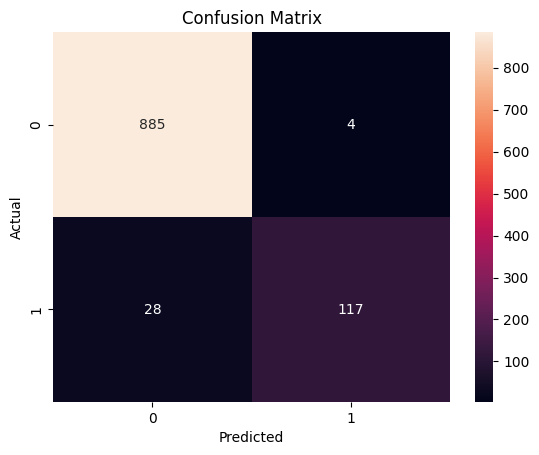

In [113]:


sns.heatmap(confusion_matrix(y_test, y_pred3), annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [114]:
# what i choose after all thinking
# tfid and mnb -----> multibornial and 


multinomila naivs bayes is best for this 

## comparision 

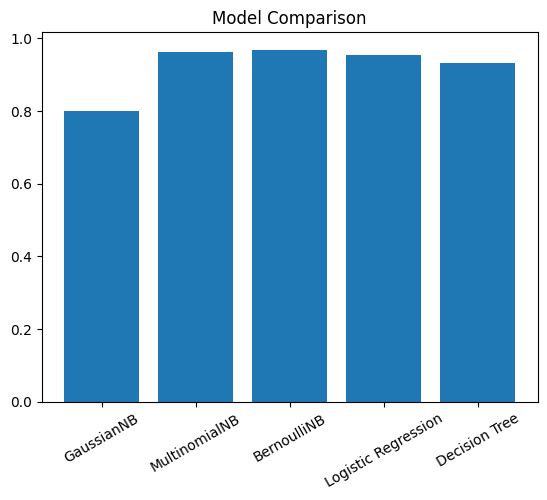

In [127]:
results = {}

results["GaussianNB"] = accuracy_score(y_test, y_pred1)
results["MultinomialNB"] = accuracy_score(y_test, y_pred2)
results["BernoulliNB"] = accuracy_score(y_test, y_pred3)
results["Logistic Regression"] = accuracy_score(y_test, y_pred4)
results["Decision Tree"] = accuracy_score(y_test, y_pred) 

# print(results)

results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])

plt.figure()
plt.bar(results_df["Model"], results_df["Accuracy"])

plt.xticks(rotation=30)
plt.title("Model Comparison")
plt.show()

In [128]:
print("Best Model:", max(results, key=results.get))

Best Model: BernoulliNB


In [115]:

import pickle
pickle.dump(tfid, open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))
